In [1]:
!pip install h2o

In [2]:
AUTOML_MAX_MODELS = 5  # 100
AUTOML_SEED = 1
AUTOML_MAX_RUNTIME_SECS = 5 * 60  # 5400

In [3]:
import os
import warnings

import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

In [4]:
USE_GOOGLE_COLAB = False

if USE_GOOGLE_COLAB:
    from google.colab import drive

    drive.mount('/content/drive')
    CSV_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
    CHALLENGE_DATA_PATH = os.path.join(os.getcwd(), 'drive', 'MyDrive', 'DSE_260A', 'data', 'cleaned_data')
    SUBMISSION_PATH = os.getcwd()
else:
    CSV_PATH = '..'
    CHALLENGE_DATA_PATH = '../cleaned_data'
    SUBMISSION_PATH = 'submission'

#Final Data cleaning for Task 4.1

In [5]:
df_train = pd.read_csv(CSV_PATH + "/merged_data/combined.csv")
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_transcriptomics = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_transcriptomics_cleaned.csv')
df_challenge = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
df_challenge = df_challenge.merge(challenge_transcriptomics, on='participant_id', how='inner')

In [6]:
#drop any d28 HAI columns which are not the target column (HAI_H1N1 A/Victoria/4897/2022_d28)
df_train = df_train.drop(columns=[c for c in df_train.columns if c.endswith('_d28') and c.startswith(
    'HAI') and c != 'HAI_H1N1 A/Victoria/4897/2022_d28'])

#filter out participants who do not have a baseline measurement for H1N1 A/Victoria/4897/2022 at day 0
df_train = df_train[df_train['HAI_H1N1 A/Victoria/4897/2022_d28'].isna() == False]

#filter out columns which are all NaN
df_train = df_train.dropna(axis=1, how='all')

In [7]:
df_train['DELTA'] = df_train['HAI_H1N1 A/Victoria/4897/2022_d28'] - df_train['HAI_H1N1 A/Victoria/4897/2022_d0']
df_train.drop(columns=['HAI_H1N1 A/Victoria/4897/2022_d28'], inplace=True)

df_train['DELTA'].value_counts()

DELTA
 0.0    152
 1.0     20
 2.0     10
-1.0      6
 3.0      6
-3.0      4
 3.0      3
-2.0      3
 4.0      3
 7.0      2
 4.0      1
-4.0      1
 1.0      1
Name: count, dtype: int64

In [8]:
df_train.head()

,participant_id,PART_biological_sex,PART_arm_name,PART_age,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H3N2 A/South Australia/34/2019_d0,HAI_H3N2 A/Tasmania/503/2020_d0,HAI_Vic B/Austria/1359417/2021_d0,HAI_Vic B/Colorado/6/2017_d0,HAI_Vic B/Washington/2/2019_d0,HAI_Yam B/Phuket/3073/2013_d0,DELTA
3466,2023_UGA.ID_002,male,Standard Fluzone,46.0,6.321928,6.321928,2.321928,6.321928,2.321928,2.321928,6.321928,5.321928,4.321928,5.321928,7.321928,6.321928,6.321928,7.321928,5.321928,0.0
3467,2023_UGA.ID_014,female,High Dose Fluzone,68.0,3.321928,3.321928,2.321928,2.321928,2.321928,4.321928,4.321928,3.321928,4.321928,6.321928,8.321928,3.321928,2.321928,2.321928,6.321928,0.0
3468,2023_UGA.ID_039,female,Standard Fluzone,28.0,8.321928,7.321928,6.321928,3.321928,2.321928,4.321928,8.321928,6.321928,8.321928,9.321928,9.321928,2.321928,2.321928,2.321928,8.321928,0.0
3469,2023_UGA.ID_058,female,Standard Fluzone,63.0,4.321928,4.321928,2.321928,2.321928,2.321928,6.321928,7.321928,5.321928,7.321928,7.321928,8.321928,5.321928,3.321928,2.321928,6.321928,0.0
3470,2023_UGA.ID_065,female,Standard Fluzone,30.0,7.321928,8.321928,4.321928,5.321928,2.321928,3.321928,9.321928,5.321928,8.321928,7.321928,8.321928,4.321928,7.321928,3.321928,9.321928,0.0


In [9]:
#figure out which columns are common to challenge and train set

challenge_cols = set(list(df_challenge.columns))
train_cols = set(list(df_train.columns))

common_cols = challenge_cols.intersection(train_cols)
print(common_cols)

missing_from_chal = train_cols - common_cols
print(missing_from_chal)

{'HAI_H3N2 A/Hong Kong/2671/2019_d0', 'participant_id', 'HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0', 'HAI_H1N1 A/Victoria/2570/2019_d0', 'HAI_Vic B/Colorado/6/2017_d0', 'HAI_Yam B/Phuket/3073/2013_d0', 'PART_age', 'HAI_Vic B/Washington/2/2019_d0', 'HAI_H3N2 A/Tasmania/503/2020_d0', 'HAI_H3N2 A/Kansas/14/2017_d0', 'HAI_H1N1 A/Victoria/4897/2022_d0', 'PART_arm_name', 'HAI_H3N2 A/South Australia/34/2019_d0', 'HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0', 'HAI_H1N1 A/California/7/2009_d0', 'HAI_Vic B/Austria/1359417/2021_d0', 'PART_biological_sex', 'HAI_H1N1 A/Brisbane/2/2018_d0', 'HAI_H3N2 A/Darwin/9/2021_d0'}
{'DELTA'}


In [10]:
df_train['PART_arm_name'] = df_train['PART_arm_name'].apply(lambda x: 1.0 if x == 'High Dose Fluzone' else 0.0)
df_train['PART_biological_sex'] = df_train['PART_biological_sex'].apply(lambda x: 1.0 if x == 'Male' else -1.0)

scaler = StandardScaler()
df_train['PART_age'] = scaler.fit_transform(df_train[['PART_age']])
df_train

,participant_id,PART_biological_sex,PART_arm_name,PART_age,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H1N1 A/California/7/2009_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_H1N1 A/Victoria/4897/2022_d0,HAI_H3N2 A/Darwin/9/2021_d0,HAI_H3N2 A/Hong Kong/2671/2019_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H3N2 A/South Australia/34/2019_d0,HAI_H3N2 A/Tasmania/503/2020_d0,HAI_Vic B/Austria/1359417/2021_d0,HAI_Vic B/Colorado/6/2017_d0,HAI_Vic B/Washington/2/2019_d0,HAI_Yam B/Phuket/3073/2013_d0,DELTA
3466,2023_UGA.ID_002,-1.0,0.0,-0.487221,6.321928,6.321928,2.321928,6.321928,2.321928,2.321928,6.321928,5.321928,4.321928,5.321928,7.321928,6.321928,6.321928,7.321928,5.321928,0.0
3467,2023_UGA.ID_014,-1.0,1.0,0.747778,3.321928,3.321928,2.321928,2.321928,2.321928,4.321928,4.321928,3.321928,4.321928,6.321928,8.321928,3.321928,2.321928,2.321928,6.321928,0.0
3468,2023_UGA.ID_039,-1.0,0.0,-1.497674,8.321928,7.321928,6.321928,3.321928,2.321928,4.321928,8.321928,6.321928,8.321928,9.321928,9.321928,2.321928,2.321928,2.321928,8.321928,0.0
3469,2023_UGA.ID_058,-1.0,0.0,0.467096,4.321928,4.321928,2.321928,2.321928,2.321928,6.321928,7.321928,5.321928,7.321928,7.321928,8.321928,5.321928,3.321928,2.321928,6.321928,0.0
3470,2023_UGA.ID_065,-1.0,0.0,-1.385401,7.321928,8.321928,4.321928,5.321928,2.321928,3.321928,9.321928,5.321928,8.321928,7.321928,8.321928,4.321928,7.321928,3.321928,9.321928,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679,2023_UGA.ID_750,-1.0,0.0,-1.609946,4.321928,4.321928,2.321928,2.321928,2.321928,2.321928,3.321928,2.321928,3.321928,4.321928,7.321928,2.321928,2.321928,2.321928,6.321928,0.0
3680,2023_UGA.ID_751,-1.0,0.0,-1.441538,7.321928,7.321928,5.321928,6.321928,2.321928,2.321928,8.321928,3.321928,4.321928,7.321928,8.321928,2.321928,2.321928,2.321928,5.321928,0.0
3681,2023_UGA.ID_753,-1.0,0.0,0.523233,8.321928,8.321928,7.321928,6.321928,5.321928,3.321928,9.321928,6.321928,7.321928,8.321928,8.321928,4.321928,4.321928,4.321928,7.321928,1.0
3682,2023_UGA.ID_754,-1.0,0.0,-0.880175,6.321928,5.321928,4.321928,2.321928,2.321928,2.321928,3.321928,2.321928,3.321928,2.321928,5.321928,4.321928,2.321928,2.321928,5.321928,7.0


#Data preprocessing for the challenge set:

In [11]:
df_challenge = df_challenge[list(common_cols)]
df_challenge['PART_arm_name'] = df_challenge['PART_arm_name'].apply(lambda x: 1.0 if x == 'High Dose Fluzone' else 0.0)
df_challenge['PART_biological_sex'] = df_challenge['PART_biological_sex'].apply(lambda x: 1.0 if x == 'Male' else -1.0)
df_challenge['PART_age'] = scaler.transform(df_challenge[['PART_age']])
df_challenge.head()

,HAI_H3N2 A/Hong Kong/2671/2019_d0,participant_id,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,HAI_H1N1 A/Victoria/2570/2019_d0,HAI_Vic B/Colorado/6/2017_d0,HAI_Yam B/Phuket/3073/2013_d0,PART_age,HAI_Vic B/Washington/2/2019_d0,HAI_H3N2 A/Tasmania/503/2020_d0,HAI_H3N2 A/Kansas/14/2017_d0,HAI_H1N1 A/Victoria/4897/2022_d0,PART_arm_name,HAI_H3N2 A/South Australia/34/2019_d0,HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d0,HAI_H1N1 A/California/7/2009_d0,HAI_Vic B/Austria/1359417/2021_d0,PART_biological_sex,HAI_H1N1 A/Brisbane/2/2018_d0,HAI_H3N2 A/Darwin/9/2021_d0
0,4.321928,2024_UGA.ID_077,3.321928,2.321928,2.321928,4.321928,0.972323,2.321928,3.321928,3.321928,2.321928,1.0,6.321928,2.321928,4.321928,4.321928,-1.0,2.321928,2.321928
1,2.321928,2024_UGA.ID_086,2.321928,6.321928,5.321928,5.321928,0.579369,4.321928,3.321928,2.321928,4.321928,1.0,4.321928,9.321928,9.321928,5.321928,-1.0,8.321928,2.321928
2,7.321928,2024_UGA.ID_128,7.321928,6.321928,3.321928,5.321928,-0.655629,3.321928,7.321928,7.321928,5.321928,0.0,8.321928,6.321928,7.321928,3.321928,-1.0,6.321928,6.321928
3,5.321928,2024_UGA.ID_170,4.321928,5.321928,2.321928,3.321928,1.084595,2.321928,6.321928,4.321928,2.321928,1.0,5.321928,3.321928,3.321928,3.321928,-1.0,3.321928,3.321928
4,3.321928,2024_UGA.ID_179,2.321928,6.321928,4.321928,7.321928,0.860050,4.321928,3.321928,6.321928,2.321928,1.0,4.321928,2.321928,3.321928,5.321928,-1.0,5.321928,4.321928


In [12]:
df_train.to_csv(os.path.join(os.getcwd(), '4.1_train_temp.csv'), index=False)

# Task 4.1

**4.1 predict magnitude of antibody response - H1N1 A/Victoria/4897/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI
* Measure: Single strain titer
* Metric: Spearman correlation
* Full description: HAI titer for H1N1 A/Victoria/4897/2022 at Day 28

In [13]:
TARGET_COL = 'DELTA'  # task 4.1

## Task 4.1: BASELINE LINNEAR REGRESSION MODEL
Magnitude refers to the strength of the antibody response against a single specific vaccine strain.
We are predicting the HAI titer for H1N1 A/Victoria/4897/2022 at Day 28 post-vaccination.

In [14]:
warnings.filterwarnings("ignore", category=UserWarning, module="h2o")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "26.0.1" 2026-04-21; OpenJDK Runtime Environment Homebrew (build 26.0.1); OpenJDK 64-Bit Server VM Homebrew (build 26.0.1, mixed mode, sharing)
  Starting server from /Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpqwh807dt
  JVM stdout: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpqwh807dt/h2o_chayan_started_from_python.out
  JVM stderr: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpqwh807dt/h2o_chayan_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 19 days
H2O_cluster_name:,H2O_from_python_chayan_m61d6u
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.98 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


In [15]:
data = h2o.import_file(os.path.join(os.getcwd(), '4.1_train_temp.csv'))

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [16]:
x = [c for c in data.columns if c != 'participant_id']
y = TARGET_COL
x = [c for c in x if c != y]

In [17]:
train, test = data.split_frame(ratios=[.8], seed=1234)

In [18]:
aml = H2OAutoML(
    max_models=AUTOML_MAX_MODELS,
    seed=AUTOML_SEED,
    nfolds=5,
    keep_cross_validation_predictions=True,
    max_runtime_secs=AUTOML_MAX_RUNTIME_SECS
)

aml.train(x=x, y=y, training_frame=train)

AutoML progress: |
15:32:43.951: AutoML: XGBoost is not available; skipping it.
15:32:43.964: _train param, Dropping bad and constant columns: [PART_biological_sex]
15:32:44.156: _train param, Dropping bad and constant columns: [PART_biological_sex]
15:32:44.156: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 169.0.
15:32:44.158: _train param, Dropping bad and constant columns: [PART_biological_sex]


15:32:44.603: _train param, Dropping bad and constant columns: [PART_biological_sex]
15:32:44.845: _train param, Dropping bad and constant columns: [PART_biological_sex]

█
15:32:45.13: _train param, Dropping bad and constant columns: [PART_biological_sex]
15:32:45.207: _train param, Dropping unused columns: [PART_biological_sex]

█
15:32:45.327: _train param, Dropping unused columns: [PART_biological_sex]

█████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,cross_validation
Number of base models (used / total),0/5
# GBM base models (used / total),0/3
# GLM base models (used / total),0/1
# DRF base models (used / total),0/1
Metalearner algorithm,GLM
Metalearner fold assignment scheme,Random
Metalearner nfolds,5
Metalearner fold_column,None
Custom metalearner hyperparameters,None


In [19]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                                                    rmse      mse       mae    rmsle    mean_residual_deviance
StackedEnsemble_AllModels_1_AutoML_1_20260531_153243     1.30496  1.70293  0.802256      nan                   1.70293
GLM_1_AutoML_1_20260531_153243                           1.30735  1.70917  0.803682      nan                   1.70917
StackedEnsemble_BestOfFamily_1_AutoML_1_20260531_153243  1.3092   1.71399  0.816787      nan                   1.71399
GBM_2_AutoML_1_20260531_153243                           1.36751  1.87008  0.878025      nan                   1.87008
GBM_4_AutoML_1_20260531_153243                           1.36851  1.87282  0.85812       nan                   1.87282
GBM_3_AutoML_1_20260531_153243                           1.38511  1.91854  0.871673      nan                   1.91854
DRF_1_AutoML_1_20260531_153243                           1.42696  2.0362   0.910264      nan                   2.0362
[7 rows x 6 columns]



In [20]:
print(aml.leader)

Model Details
H2OStackedEnsembleEstimator : Stacked Ensemble
Model Key: StackedEnsemble_AllModels_1_AutoML_1_20260531_153243


Model Summary for Stacked Ensemble: 
key                                   value
------------------------------------  ----------------
Stacking strategy                     cross_validation
Number of base models (used / total)  0/5
# GBM base models (used / total)      0/3
# GLM base models (used / total)      0/1
# DRF base models (used / total)      0/1
Metalearner algorithm                 GLM
Metalearner fold assignment scheme    Random
Metalearner nfolds                    5
Metalearner fold_column
Custom metalearner hyperparameters    None

ModelMetricsRegressionGLM: stackedensemble
** Reported on train data. **

MSE: 1.6846048807814853
RMSE: 1.2979232954152127
MAE: 0.7989216063863309
RMSLE: NaN
Mean Residual Deviance: 1.6846048807814853
R^2: -2.220446049250313e-16
Null degrees of freedom: 168
Residual degrees of freedom: 168
Null deviance: 284.698224852

In [21]:
predictions = aml.leader.predict(test)

results = test[y].cbind(predictions["predict"])
results.columns = ["actual", "predicted"]

# Filter out rows where actual is NaN
results_clean = results[results["actual"].isna() == 0]

print(results_clean.head(20))

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
  actual    predicted
       0      0.35503
       0      0.35503
       0      0.35503
       0      0.35503
       0      0.35503
       0      0.35503
       0      0.35503
       0      0.35503
      -3      0.35503
       0      0.35503
       0      0.35503
      -1      0.35503
       0      0.35503
       0      0.35503
       0      0.35503
       0      0.35503
       0      0.35503
       1      0.35503
       1      0.35503
       0      0.35503
[20 rows x 2 columns]



Spearman (results_clean): nan  (p-value: nan)


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_19735/2775907529.py:4: ConstantInputWarning

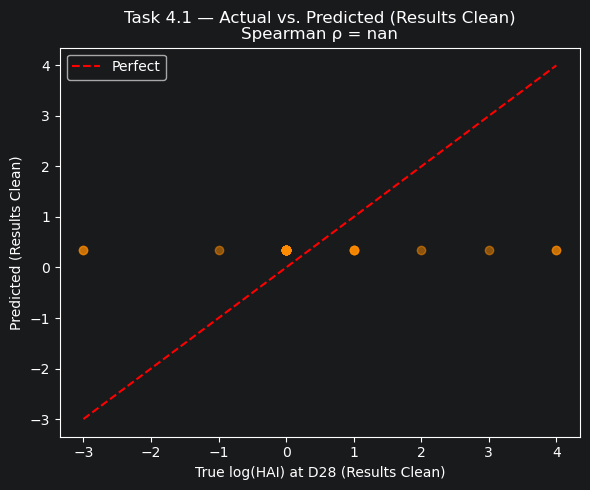

In [22]:
actual_values = results_clean['actual'].as_data_frame(use_multi_thread=True).to_numpy()
predicted_values = results_clean['predicted'].as_data_frame(use_multi_thread=True).to_numpy()

rho_results, pval_results = spearmanr(actual_values, predicted_values)
print(f'Spearman (results_clean): {rho_results:.3f}  (p-value: {pval_results:.4f})')

plt.figure(figsize=(6, 5))
plt.scatter(actual_values, predicted_values, alpha=0.5, color='darkorange')
plt.plot([actual_values.min(), actual_values.max()], [actual_values.min(), actual_values.max()], 'r--', label='Perfect')
plt.xlabel('True log(HAI) at D28 (Results Clean)')
plt.ylabel('Predicted (Results Clean)')
plt.title(f'Task 4.1 — Actual vs. Predicted (Results Clean)\nSpearman ρ = {rho_results:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

First 5 actual HAI D28 values (Original Scale):
 [[5.]
 [5.]
 [5.]
 [5.]
 [5.]]

First 5 predicted HAI D28 values (Original Scale):
 [[6.39505905]
 [6.39505905]
 [6.39505905]
 [6.39505905]
 [6.39505905]]


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


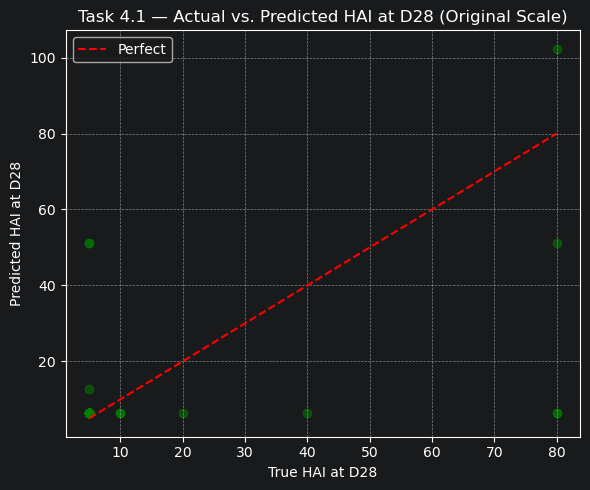

In [23]:
# Flag to toggle between log scale (1) and original scale (0) results
convert_to_original_scale = 0  # Set to 0 for original scale, 1 for log2 scale

# Get the Day 0 HAI values for the test set corresponding to the cleaned results
test_d0_hai_column_name = TARGET_COL.replace('DELTA', 'HAI_H1N1 A/Victoria/4897/2022_d0')

# Filter the original 'test' H2OFrame using the same condition that created results_clean.
# results_clean was created from `results[results["actual"].isna() == 0]`,
# where `results["actual"]` corresponds to `test[y]` for the relevant rows.
filtered_test_for_d0_h2o = test[test[y].isna() == 0]

# Now, extract the d0 HAI column from this filtered H2OFrame
test_d0_hai_h2o_filtered = filtered_test_for_d0_h2o[test_d0_hai_column_name]

# Convert it to a numpy array. The 'actual_values' and 'predicted_values' are already numpy arrays.
test_d0_hai = test_d0_hai_h2o_filtered.as_data_frame(use_multi_thread=True).values.reshape(-1, 1)

# Calculate actual HAI d28 values (log2 scale)
actual_hai_d28_log2 = test_d0_hai + actual_values

# Calculate predicted HAI d28 values (log2 scale)
predicted_hai_d28_log2 = test_d0_hai + predicted_values

if convert_to_original_scale == 0:
    # Convert to original HAI titer scale (exp2)
    display_actual_values = np.exp2(actual_hai_d28_log2)
    display_predicted_values = np.exp2(predicted_hai_d28_log2)
    scale_label = 'Original Scale'
    x_label = 'True HAI at D28'
    y_label = 'Predicted HAI at D28'
else:
    display_actual_values = actual_hai_d28_log2
    display_predicted_values = predicted_hai_d28_log2
    scale_label = 'Log2 Scale'
    x_label = 'True log2(HAI) at D28'
    y_label = 'Predicted log2(HAI) at D28'

print(f"First 5 actual HAI D28 values ({scale_label}):\n", display_actual_values[:5])
print(f"\nFirst 5 predicted HAI D28 values ({scale_label}):\n", display_predicted_values[:5])

# Plotting the HAI values
plt.figure(figsize=(6, 5))
plt.scatter(display_actual_values, display_predicted_values, alpha=0.5, color='green')
plt.plot([display_actual_values.min(), display_actual_values.max()],
         [display_actual_values.min(), display_actual_values.max()], 'r--', label='Perfect')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(f'Task 4.1 — Actual vs. Predicted HAI at D28 ({scale_label})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [24]:
#calculate the spearman
rho_results, pval_results = spearmanr(display_actual_values, display_predicted_values)

print(f'Spearman: {rho_results}')

Spearman: 0.24479473713626676


#Use AutoML model to predict challenge set

In [25]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
top_model = h2o.get_model(lb_df['model_id'].iloc[0])

challenge_hf = h2o.H2OFrame(df_challenge)
try:
    y_pred_challenge = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']
except OSError:
    fallback_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
    top_model = h2o.get_model(fallback_id)
    y_pred_challenge = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

results = pd.DataFrame({
    'participant_id': df_challenge['participant_id'].values,
    'Task_4.1': np.exp2(y_pred_challenge),
})

results = results.merge(df_challenge[['participant_id', 'HAI_H1N1 A/Victoria/4897/2022_d0']], on='participant_id',
                        how='inner')
results['Task_4.1'] = np.exp2(results['Task_4.1'] + results['HAI_H1N1 A/Victoria/4897/2022_d0'])
d0 = results.copy(deep=True)
results.drop(columns=['HAI_H1N1 A/Victoria/4897/2022_d0'], inplace=True)
results

Parse progress: |

/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: | (failed)
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,participant_id,Task_4.1
0,2024_UGA.ID_077,12.142284
1,2024_UGA.ID_086,49.231501
2,2024_UGA.ID_128,96.176036
3,2024_UGA.ID_170,12.069933
4,2024_UGA.ID_179,12.116785
5,2024_UGA.ID_215,12.086504
6,2024_UGA.ID_219,12.284054
7,2024_UGA.ID_275,24.254880
8,2024_UGA.ID_295,48.633012
9,2024_UGA.ID_296,12.296256


In [26]:
d0

,participant_id,Task_4.1,HAI_H1N1 A/Victoria/4897/2022_d0
0,2024_UGA.ID_077,12.142284,2.321928
1,2024_UGA.ID_086,49.231501,4.321928
2,2024_UGA.ID_128,96.176036,5.321928
3,2024_UGA.ID_170,12.069933,2.321928
4,2024_UGA.ID_179,12.116785,2.321928
5,2024_UGA.ID_215,12.086504,2.321928
6,2024_UGA.ID_219,12.284054,2.321928
7,2024_UGA.ID_275,24.254880,3.321928
8,2024_UGA.ID_295,48.633012,4.321928
9,2024_UGA.ID_296,12.296256,2.321928


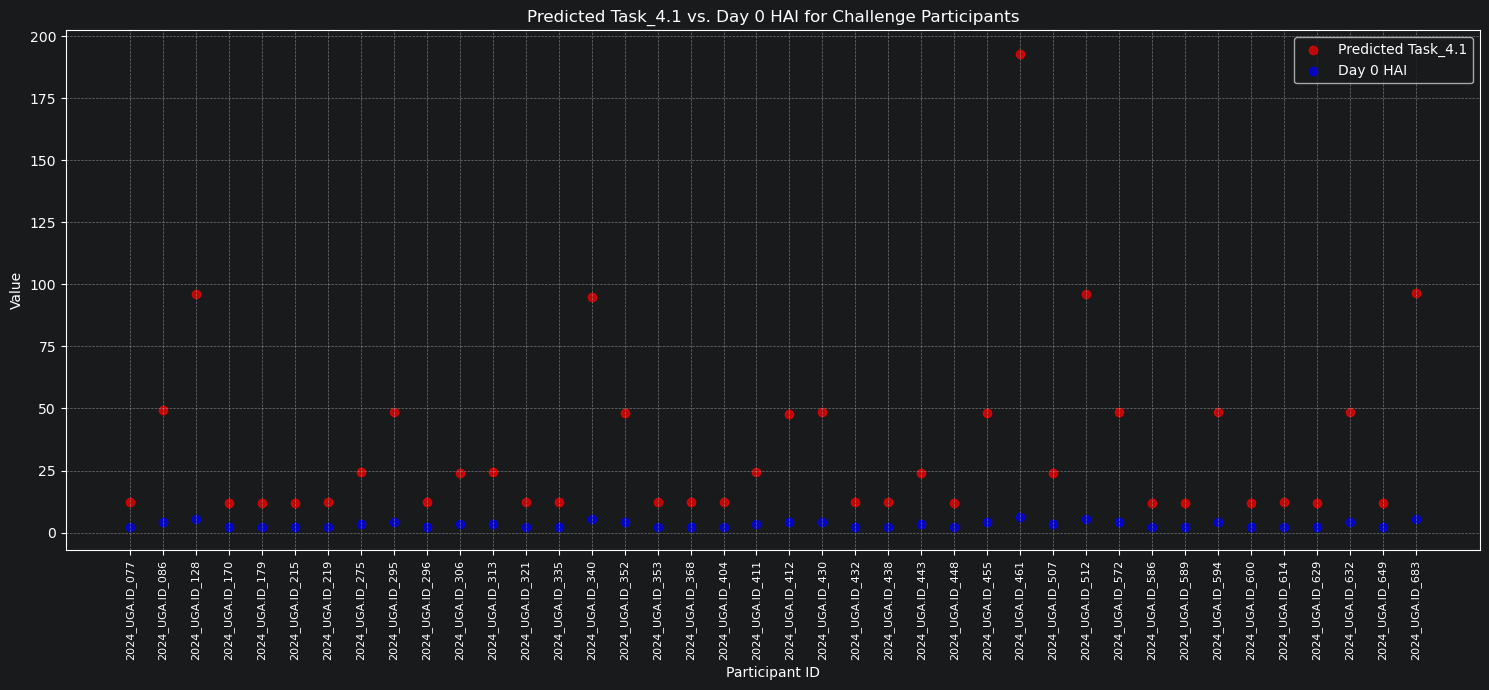

In [27]:
plt.figure(figsize=(15, 7))

# Plot predicted Task_4.1 values
plt.scatter(d0['participant_id'], d0['Task_4.1'], color='red', label='Predicted Task_4.1', alpha=0.7)

# Plot Day 0 HAI values (d0 value)
plt.scatter(d0['participant_id'], d0['HAI_H1N1 A/Victoria/4897/2022_d0'], color='blue', label='Day 0 HAI', alpha=0.7)

plt.xlabel('Participant ID')
plt.ylabel('Value')
plt.title('Predicted Task_4.1 vs. Day 0 HAI for Challenge Participants')
plt.xticks(rotation=90, fontsize=8)  # Rotate x-axis labels for readability
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [28]:
#output to csv
results.to_csv(SUBMISSION_PATH + '/task_4_1.csv', index=False)